# Gene-Range Perturbation — Multi-Slide Analysis

In [35]:
%matplotlib inline
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 200,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 17,
    'axes.labelsize': 18,
    'axes.titlesize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

RED_LIGHT = '#FC9272'   # Global logFC
RED_MID   = '#CB181D'   # Cell-type-specific logFC
RED_DARK  = '#67000D'   # Edge swap baseline

# kept for cell-7 boxplots
BLUE   = '#2166AC'
ORANGE = '#D6604D'
GREEN  = '#4DAC26'

TOP_N_PERTURB_VALUES = [10, 20, 50, 100, 200, 500, 1000, 2000, 3000]

## 1. Load results across all slides

In [ ]:
results_root = 'results/gene_range_pr/'
csvs = sorted(glob.glob(f'{results_root}/*/results.csv'))

dfs = []
for p in csvs:
    sid = int(Path(p).parent.name)
    df = pd.read_csv(p)
    df['slide_id'] = sid
    dfs.append(df)

if not dfs:
    raise FileNotFoundError(f'No results.csv files found under {results_root}/*/. Run perturb_gene_range.py first.')

all_df = pd.concat(dfs, ignore_index=True)
slide_ids = sorted(all_df['slide_id'].unique().tolist())
print(f'Loaded {len(dfs)} slide(s): {slide_ids}')
print(f'Total rows: {len(all_df)}')

# Convenience subsets
sweep_mean    = all_df[(all_df['cell_type'] == 'mean') & all_df['top_n_perturb'].notna()].copy()
baseline_mean = all_df[(all_df['cell_type'] == 'mean') & all_df['top_n_perturb'].isna()].copy()
ct_at_200     = all_df[(all_df['top_n_perturb'] == 200) & (all_df['cell_type'] != 'mean')].copy()
ct_baseline   = all_df[all_df['top_n_perturb'].isna() & (all_df['cell_type'] != 'mean')].copy()

sweep_mean['top_n_perturb'] = sweep_mean['top_n_perturb'].astype(int)

Loaded 6 slide(s): [120, 210, 221, 231, 232, 242]
Total rows: 1007


## 2. Summary plot with CI across slides

In [37]:
all_df.sort_values("spearman_r")

,pearson_r,spearman_r,precision,direction_match,edistance,edistance_local,rmse_log1p,strategy,cell_type,top_n_perturb,slide_id
511,-0.397087,-0.538439,0.24,0.083333,11.618824,7.105255,2087.479736,ctspec,Smooth_muscle,2000.0,221
520,-0.522453,-0.530948,0.32,0.062500,12.190424,7.361031,2096.642090,global,Smooth_muscle,3000.0,221
514,-0.616755,-0.529508,0.16,0.000000,8.201765,5.120476,295.317383,global,B_cell,3000.0,221
529,-0.458675,-0.513277,0.26,0.076923,11.018198,6.386260,2075.927246,ctspec,Smooth_muscle,3000.0,221
510,-0.536607,-0.492341,0.10,0.000000,8.962608,5.140572,1379.084961,ctspec,Plasma_cell,2000.0,221
...,...,...,...,...,...,...,...,...,...,...,...
733,0.994516,0.975222,0.82,1.000000,0.413463,0.394155,31103.824219,ctspec,Epithelial,50.0,232
781,0.995632,0.977623,0.88,1.000000,0.499102,0.410676,30970.130859,ctspec,Epithelial,500.0,232
749,0.995533,0.977719,0.84,1.000000,0.318936,0.398325,31069.302734,ctspec,Epithelial,100.0,232
685,0.996823,0.980120,0.88,1.000000,0.312450,0.273645,31027.212891,edge_swap,Epithelial,NaN,232


In [38]:
all_df['slide_id'].unique()

array([120, 210, 221, 231, 232, 242])

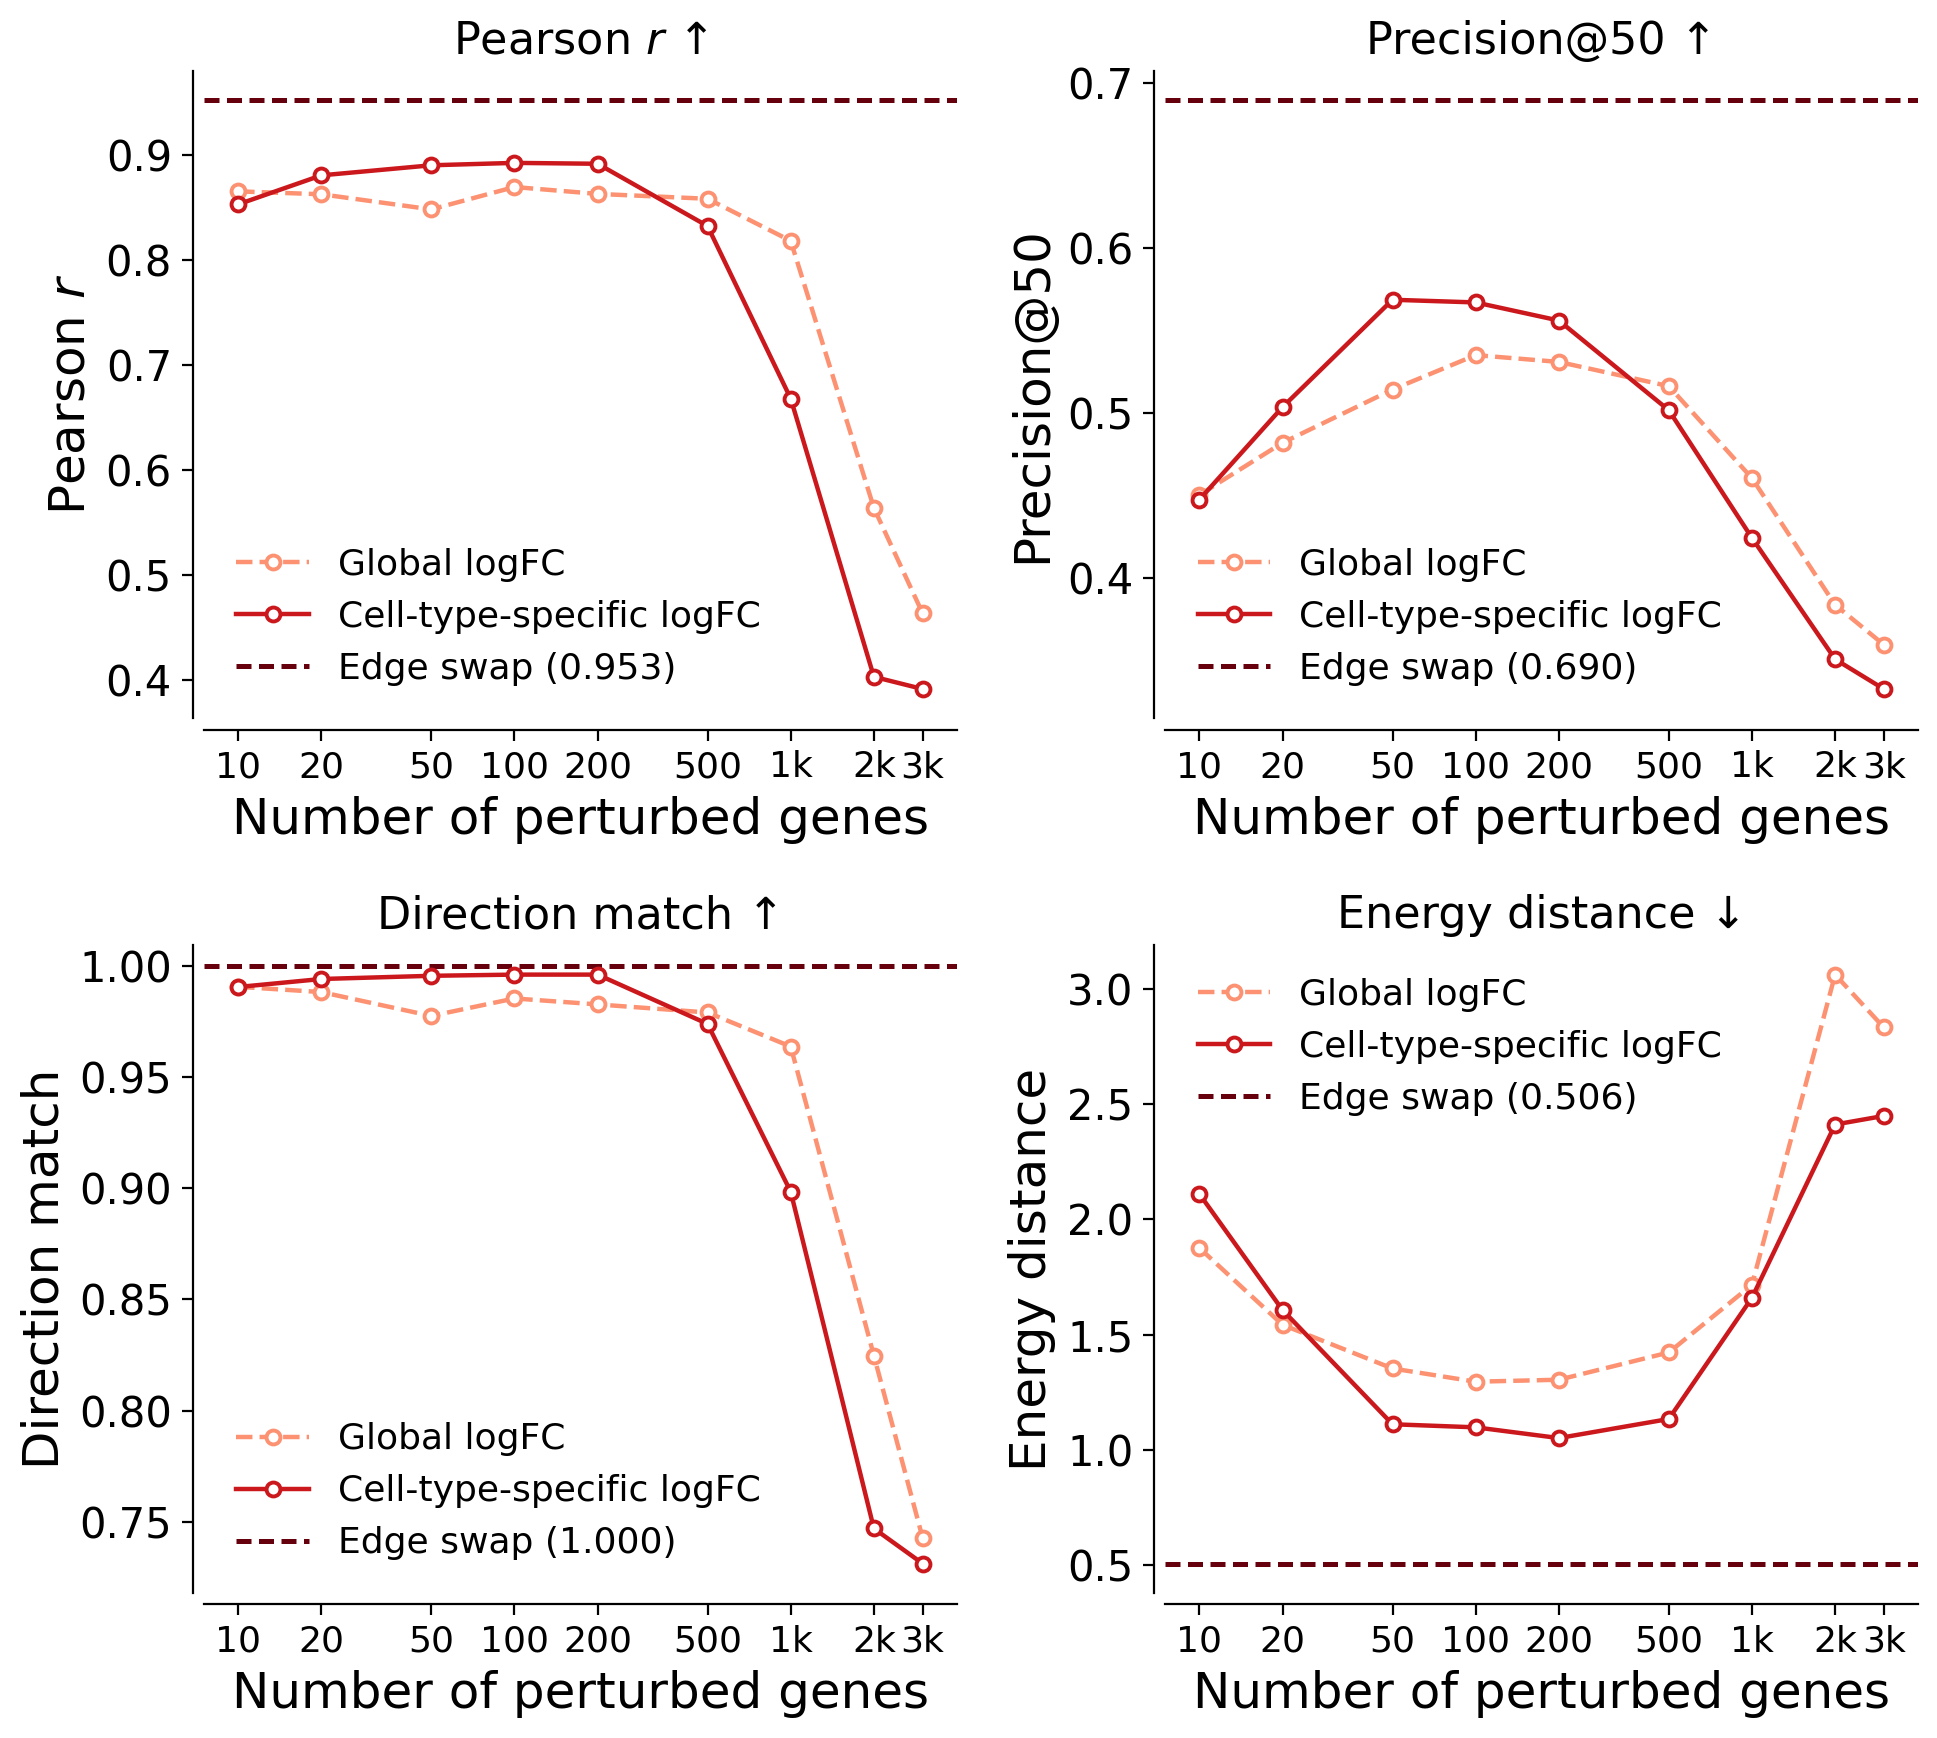

In [41]:
metrics_spec = [
    ('pearson_r',       'Pearson $r$',             True),
    # ('spearman_r',      'Spearman $r$',             True),
    ('precision',       'Precision@50',             True),
    ('direction_match', 'Direction match',           True),
    # ('edistance',       'Energy distance',           False),
    ('edistance_local', 'Energy distance',   False),
    # ('rmse_log1p',      'RMSE log1p',               False),
]

TICK_LABELS = ['10', '20', '50', '100', '200', '500', '1k', '2k', '3k']

ncols = 2
nrows = -(-len(metrics_spec) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.0, nrows * 4.5))
axes = axes.flatten()

for i, (metric, ylabel, higher_better) in enumerate(metrics_spec):
    ax = axes[i]
    arrow = ' ↑' if higher_better else ' ↓'

    for strategy, color, ls, label in [
        ('global', RED_LIGHT, '--', 'Global logFC'),
        ('ctspec', RED_MID,   '-',  'Cell-type-specific logFC'),
    ]:
        sub = sweep_mean[sweep_mean['strategy'] == strategy]
        grp = sub.groupby('top_n_perturb')[metric]
        means = grp.mean().reindex(TOP_N_PERTURB_VALUES)
        stds  = grp.std(ddof=1).reindex(TOP_N_PERTURB_VALUES).fillna(0)
        x = means.index.tolist()

        ax.plot(x, means, color=color, ls=ls, lw=1.6,
                marker='o', ms=5, markerfacecolor='white', markeredgewidth=1.4,
                label=label, zorder=3)

    # Edge-swap baseline (mean only)
    bl = baseline_mean[baseline_mean['strategy'] == 'edge_swap'][metric]
    bl_mean = bl.mean()
    ax.axhline(bl_mean, color=RED_DARK, ls=(0, (3, 1.5)), lw=1.8,
               label=f'Edge swap ({bl_mean:.3f})', zorder=2)

    ax.set_xscale('log')
    ax.set_xticks(TOP_N_PERTURB_VALUES)
    ax.set_xticklabels(TICK_LABELS, rotation=45, ha='right')
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.set_xlabel('Number of perturbed genes')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + arrow)
    ax.spines['left'].set_position(('outward', 4))
    ax.spines['bottom'].set_position(('outward', 4))
    ax.legend(frameon=False, handlelength=2.0, fontsize=13)

for j in range(len(metrics_spec), len(axes)):
    axes[j].set_visible(False)

# fig.suptitle(f'Slides: {slide_ids}', fontsize=11, y=1.01)
fig.tight_layout()
plt.savefig('convergence.png', bbox_inches='tight')
plt.show()

In [43]:
metrics = [m for m, _, _ in metrics_spec]

# Per-(strategy, top_n) aggregation — one row per point on the plot
agg = (
    sweep_mean[sweep_mean['strategy'].isin(['global', 'ctspec'])]
    .groupby(['strategy', 'top_n_perturb'])[metrics]
    .agg(['mean', 'std'])
    .reindex(TOP_N_PERTURB_VALUES, level='top_n_perturb')
)

# Edge-swap baseline (one number per metric — the dashed horizontal line)
baseline = (
    baseline_mean[baseline_mean['strategy'] == 'edge_swap'][metrics]
    .mean()
    .rename('edge_swap_mean')
)

In [44]:
agg

pearson_r           precision            \
                            mean       std      mean       std   
strategy top_n_perturb                                           
ctspec   10             0.853353  0.063200  0.447440  0.063548   
         20             0.881010  0.059893  0.503558  0.075720   
         50             0.890615  0.075570  0.568664  0.084083   
         100            0.892906  0.081621  0.567037  0.105321   
         200            0.892063  0.080982  0.556052  0.104180   
         500            0.832638  0.134955  0.501647  0.137057   
         1000           0.668048  0.344479  0.424160  0.150513   
         2000           0.402582  0.410653  0.350575  0.142766   
         3000           0.390961  0.390074  0.332526  0.140592   
global   10             0.865740  0.031408  0.450251  0.045454   
         20             0.862962  0.075281  0.481905  0.089283   
         50             0.848534  0.120369  0.514180  0.111516   
         100            0.869882  0.113560  0.535073  0.092528   
         200            0.863305  0.123354  0.530946  0.092886   
         500            0.858675  0.117895  0.516257  0.108761   
         1000           0.818524  0.115579  0.460417  0.148954   
         2000           0.563698  0.405182  0.383571  0.145753   
         3000           0.463353  0.532198  0.359418  0.144532   

                       direction_match           edistance_local            
                                  mean       std            mean       std  
strategy top_n_perturb                                                      
ctspec   10                   0.990462  0.011182        2.110165  1.129423  
         20                   0.994060  0.007776        1.606245  0.948212  
         50                   0.995498  0.007048        1.110443  0.481353  
         100                  0.996032  0.009720        1.097058  0.541413  
         200                  0.996032  0.009720        1.050476  0.444292  
         500                  0.973869  0.049536        1.133261  0.637322  
         1000                 0.898437  0.180536        1.659529  1.199172  
         2000                 0.747067  0.297502        2.411816  2.122293  
         3000                 0.731325  0.274796        2.449062  1.924879  
global   10                   0.990555  0.009989        1.875855  0.882780  
         20                   0.988185  0.013636        1.542096  0.907581  
         50                   0.977455  0.034831        1.352537  0.455008  
         100                  0.985310  0.029074        1.295163  0.399003  
         200                  0.982639  0.034513        1.303752  0.420999  
         500                  0.979005  0.040267        1.422102  0.564418  
         1000                 0.963699  0.045583        1.715850  0.717163  
         2000                 0.824770  0.246852        3.062554  1.898859  
         3000                 0.742950  0.369028        2.833190  2.564367

## 3. Per-cell-type boxplots at 200 genes

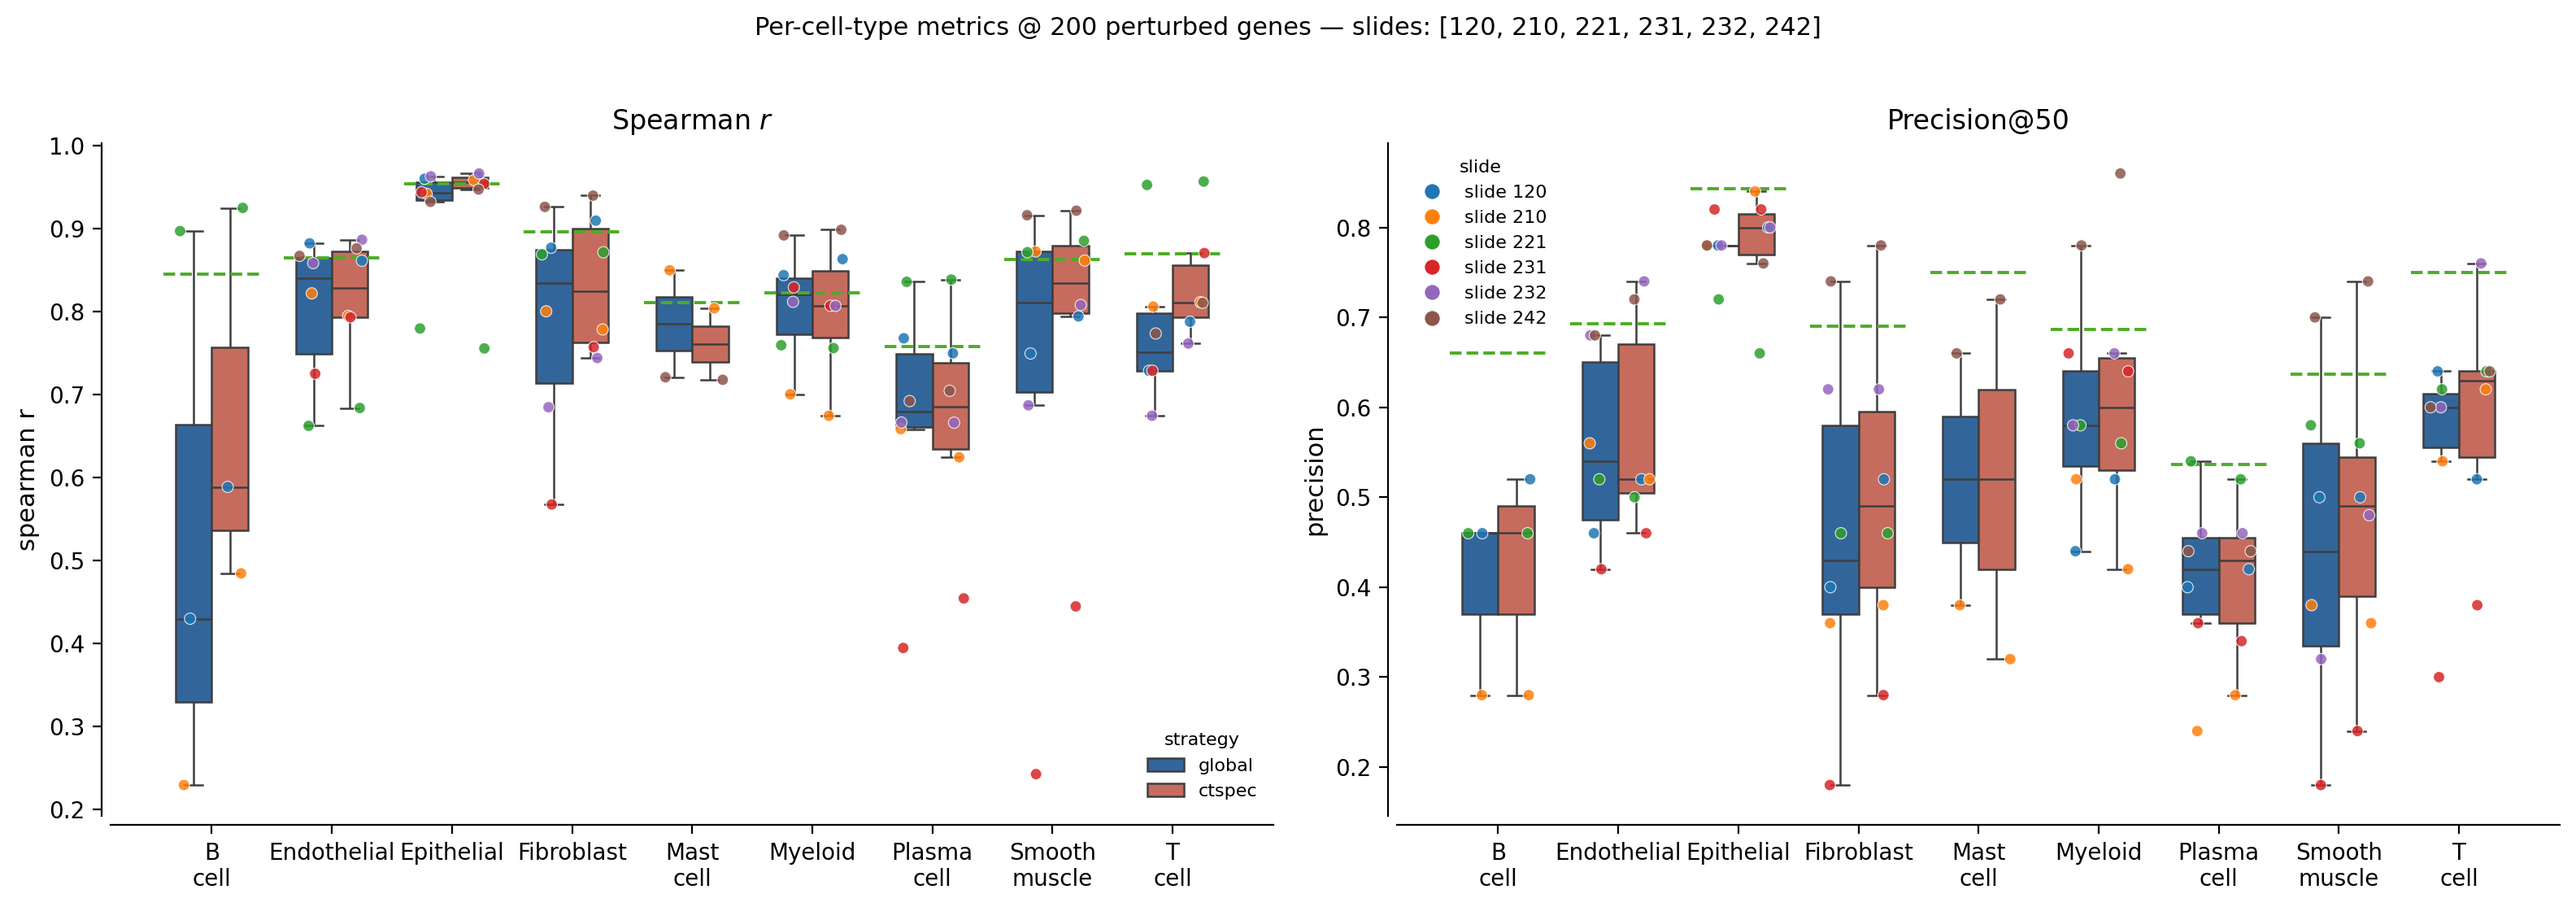

In [7]:
import numpy as np

cell_types = sorted(ct_at_200['cell_type'].unique().tolist())
strategies = ['global', 'ctspec']
strategy_palette = {'global': BLUE, 'ctspec': ORANGE}

plot_specs = [
    ('spearman_r', r'Spearman $r$'),
    ('precision',  'Precision@50'),
]

slides = sorted(ct_at_200['slide_id'].unique())
slide_cmap = dict(zip(slides, sns.color_palette('tab10', n_colors=len(slides))))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
rng = np.random.default_rng(0)

for ax, (metric, title) in zip(axes, plot_specs):
    sns.boxplot(
        data=ct_at_200, x='cell_type', y=metric, hue='strategy',
        order=cell_types, hue_order=strategies,
        palette=strategy_palette,
        ax=ax, width=0.6, linewidth=0.9,
        flierprops=dict(marker='', markersize=0),
    )

    # Manual point overlay: offset by strategy (to match dodged boxes), color by slide_id
    for ct_idx, ct in enumerate(cell_types):
        for strat_idx, strat in enumerate(strategies):
            sub = ct_at_200[(ct_at_200['cell_type'] == ct) &
                            (ct_at_200['strategy'] == strat)]
            if len(sub) == 0:
                continue
            offset = -0.2 if strat_idx == 0 else 0.2
            xs = ct_idx + offset + rng.uniform(-0.07, 0.07, len(sub))
            colors = [slide_cmap[s] for s in sub['slide_id']]
            ax.scatter(xs, sub[metric].values, c=colors,
                       s=25, alpha=0.85, zorder=4,
                       edgecolors='white', linewidths=0.4)

    # Per-cell-type edge-swap baseline (spans both strategy boxes)
    bl_sub = ct_baseline[ct_baseline['strategy'] == 'edge_swap']
    for xi, ct in enumerate(cell_types):
        ct_bl = bl_sub[bl_sub['cell_type'] == ct][metric]
        if len(ct_bl) > 0:
            ax.hlines(ct_bl.mean(), xi - 0.4, xi + 0.4,
                      colors=GREEN, linewidths=1.4, linestyles='--', zorder=3)

    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(metric.replace('_', ' '))
    ax.set_xticks(range(len(cell_types)))
    ax.set_xticklabels([ct.replace('_', '\n') for ct in cell_types],
                       rotation=0, fontsize=9)
    ax.spines['left'].set_position(('outward', 4))
    ax.spines['bottom'].set_position(('outward', 4))

    # Legends: strategy on the left panel, slide_id on the right panel
    if ax is axes[0]:
        strat_handles, strat_labels = ax.get_legend_handles_labels()
        ax.legend(strat_handles, strat_labels, title='strategy',
                  loc='best', frameon=False, fontsize=8, title_fontsize=8)
    else:
        if ax.get_legend():
            ax.get_legend().remove()
        slide_handles = [plt.Line2D([0], [0], marker='o', color='w',
                                    markerfacecolor=slide_cmap[s],
                                    markeredgecolor='white', markeredgewidth=0.4,
                                    markersize=7, label=f'slide {s}')
                         for s in slides]
        ax.legend(handles=slide_handles, title='slide',
                  loc='best', frameon=False, fontsize=8, title_fontsize=8)

fig.suptitle(f'Per-cell-type metrics @ 200 perturbed genes — slides: {slide_ids}',
             fontsize=11, y=1.01)
fig.tight_layout()
plt.show()